In [1]:
import agweatherqaqc as awqc
import numpy as np
import glob
import pandas as pd
import configparser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
# Create a ConfigParser object
config = configparser.ConfigParser()

In [2]:

def plot_sensor_anomalies(df,
                          site,
                          rso_col='rso',
                          sensors=('SW_IN_1_1_1','SW_IN_1_1_2'),
                          rolling_window=15,
                          start=None,
                          end=None,
                          bins=50):
    """
    Compare sensor(s) to modeled clear-sky rso by plotting anomalies and printing stats.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by datetime and containing columns for rso and the sensors.
    rso_col : str
        Column name of modeled clear-sky shortwave (rso).
    sensors : iterable of str
        Sensor column names to compare.
    rolling_window : int
        Window (in rows) for plotting a rolling mean smoother of anomalies.
    start, end : str or pd.Timestamp, optional
        Slice range for df. If None, use entire df.
    bins : int
        Number of bins for histogram.
    """
    # Slice if requested
    df = df.copy()
    if start is not None or end is not None:
        df = df.loc[start:end]
    fig, axs = plt.subplots(figsize=(8,4),nrows=2, ncols=1, sharex=True)
    i=0
    colors=['orange','lightblue']
    for s in sensors:
        if s not in df.columns:
            print(f"Column '{s}' not in dataframe — skipping.")
            continue
        if rso_col not in df.columns:
            raise ValueError(f"rso column '{rso_col}' not in dataframe")

        mask = df[rso_col].notna() & df[s].notna()
        if mask.sum() == 0:
            print(f"No overlapping data for {s} and {rso_col}.")
            continue

        rso = df.loc[mask, rso_col].astype(float)
        sens = df.loc[mask, s].astype(float)
        err = sens - rso                     # absolute anomaly (W m^-2)
        with np.errstate(divide='ignore', invalid='ignore'):
            pct_err = err / rso * 100        # percent error (avoid divide by zero)

        # Summary stats
        bias = err.rolling(window=rolling_window, center=True, min_periods=int(np.round(rolling_window/2,0)-1)).median().mean()
        mae = np.abs(err.rolling(window=rolling_window, center=True, min_periods=int(np.round(rolling_window/2,0)-1)).median()).mean()
        rmse = sqrt((err**2).mean())
        # Pearson r
        if len(rso) > 1:
            r = np.corrcoef(rso, sens)[0,1]
        else:
            r = np.nan

        print(f"\n\n{site}")
        print(f"--- {s} vs {rso_col} ---")
        print(f"Points compared: {len(err)}")
        print(f"Bias (of {str(rolling_window)} day median anomaly) : {bias:.2f} W/m^2")
        print(f"MAE (of {str(rolling_window)} day median anomaly)  : {mae:.2f} W/m^2")
        print(f"RMSE                    : {rmse:.2f} W/m^2")
        print(f"Pearson r               : {r:.3f}")
        print(f"Percent error (median)  : {np.nanmedian(pct_err):.2f} %")
        print()

        # 1) Time series of anomalies with rolling mean
        df['zeros']=0
        err.plot(label='raw anomaly',ax=axs[i],color=colors[i],linestyle='-.')
        if rolling_window and rolling_window > 1:
            err.rolling(window=rolling_window, center=True, min_periods=int(np.round(rolling_window/2,0)-1)).median().plot(label=f'rolling median ({rolling_window})',ax=axs[i],color=colors[i])
        df.zeros.plot(linestyle=":",ax=axs[i],color='gray')
        axs[i].set_title(site+f"\n {s} - {rso_col} (anomaly) — bias {bias:.2f} W/m^2")
        axs[i].set_xlabel(" ")
        axs[i].set_ylabel("Anomaly (W/m2)")
        axs[i].legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
        i+=1
    fig.subplots_adjust(hspace=0.35)


def diag_netrad(in_df,site,sensor1name = 'S1',sensor2name = 'S2'):
    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(figsize=(8,12),nrows=4, ncols=1, sharex=True)
    ax1.set_title(site+ '\nShortwave radiation')
    ax1.set_ylabel('W/m2')
    ax1.grid(True)
    in_df.SW_IN_1_1_1.plot(label=sensor1name, color='orange', ax=ax1)
    in_df.SW_IN_1_1_2.plot(label=sensor2name, color='lightblue', ax=ax1)
    in_df.SW_OUT_1_1_1.plot(label='', color='orange',linestyle=':', ax=ax1)
    in_df.SW_OUT_1_1_2.plot(label='', color='lightblue', linestyle=':', ax=ax1)
    in_df.rso.plot(label='clear sky model', color='k', ax=ax1)    
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    ax2.set_title('Longwave Radiation')
    ax2.set_ylabel('W/m2')
    ax2.grid(True)
    in_df.LW_IN_1_1_1.plot(label=sensor1name,color='orange', ax=ax2)
    in_df.LW_IN_1_1_2.plot(label=sensor2name,color='lightblue', ax=ax2)
    in_df.LW_OUT_1_1_1.plot(label=sensor1name,color='orange',linestyle=':', ax=ax2)
    in_df.LW_OUT_1_1_2.plot(label=sensor2name, color='lightblue', linestyle=':', ax=ax2)
    
    ax3.set_xlabel('Date') # 
    ax3.set_ylabel('W/m2')
    ax3.set_title('Net Radiation')

    in_df.NETRAD_1_1_1_FINAL.plot(ax=ax3,color='orange')
    in_df.NETRAD_1_1_2_FINAL.plot(ax=ax3,color='lightblue')

    in_df['NETRAD_DIF']=in_df.NETRAD_1_1_1_FINAL-in_df.NETRAD_1_1_2_FINAL
    in_df['LW_DIFin']= in_df.LW_IN_1_1_1-in_df.LW_IN_1_1_2
    in_df['LW_DIFout']= -1*(in_df.LW_OUT_1_1_1-in_df.LW_OUT_1_1_2)
    in_df['LW_DIF_net'] = (in_df.LW_IN_1_1_1-in_df.LW_OUT_1_1_1)-(in_df.LW_IN_1_1_2-in_df.LW_OUT_1_1_2)
    in_df['SW_outDIF']= -1*(in_df.SW_OUT_1_1_1-in_df.SW_OUT_1_1_2)
    in_df['SW_inDIF']= in_df.SW_IN_1_1_1-in_df.SW_IN_1_1_2
    in_df['SW_DIF_net'] = (in_df.SW_IN_1_1_1-in_df.SW_OUT_1_1_1)-(in_df.SW_IN_1_1_2-in_df.SW_OUT_1_1_2)
    
    ax4.set_xlabel('Date') # 
    ax4.set_ylabel('W/m2')
    ax4.set_title('Component Differences (S1 - S2)')
    in_df['NETRAD_DIF'].plot(color='darkgray',ax=ax4,lw=4)
    in_df.SW_DIF_net.plot(color='red',ax=ax4, style=':',lw=2)
    in_df.LW_DIF_net.plot(color='purple',ax=ax4, style=':',lw=2)
    in_df['SW_inDIF'].plot(color='yellow',ax=ax4, style=':',lw=1)
    in_df['SW_outDIF'].plot(color='orange',ax=ax4, style=':', lw=1)
    in_df['LW_DIFin'].plot(color='dodgerblue',ax=ax4, style=':',lw=1)
    in_df['LW_DIFout'].plot(color='darkblue',ax=ax4, style=':',lw=1)
    
    ax4.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    ax4.set_ylim([-65,65])

    fig.subplots_adjust(hspace=0.35)

data/dugout/US-UTD_nr2_gsv1.ini
SW_IN_1_1_2
SW_OUT_1_1_2
UFLUX Dugout Ranch
All required columns are present.
(826,)


UFLUX Dugout Ranch
--- SW_IN_1_1_1 vs rso ---
Points compared: 748
Bias (of 8 day median anomaly) : -26.28 W/m^2
MAE (of 8 day median anomaly)  : 30.72 W/m^2
RMSE                    : 64.87 W/m^2
Pearson r               : 0.824
Percent error (median)  : -7.12 %



UFLUX Dugout Ranch
--- SW_IN_1_1_2 vs rso ---
Points compared: 746
Bias (of 8 day median anomaly) : -31.83 W/m^2
MAE (of 8 day median anomaly)  : 32.90 W/m^2
RMSE                    : 65.61 W/m^2
Pearson r               : 0.844
Percent error (median)  : -8.43 %

data/escalante/US-UTE_nr1_soilvue_alldata.ini
SW_IN_1_1_1
SW_OUT_1_1_1
UFLUX Escalante
All required columns are present.
(478,)


UFLUX Escalante
--- SW_IN_1_1_1 vs rso ---
Points compared: 381
Bias (of 8 day median anomaly) : -23.06 W/m^2
MAE (of 8 day median anomaly)  : 26.34 W/m^2
RMSE                    : 62.57 W/m^2
Pearson r               : 0.79

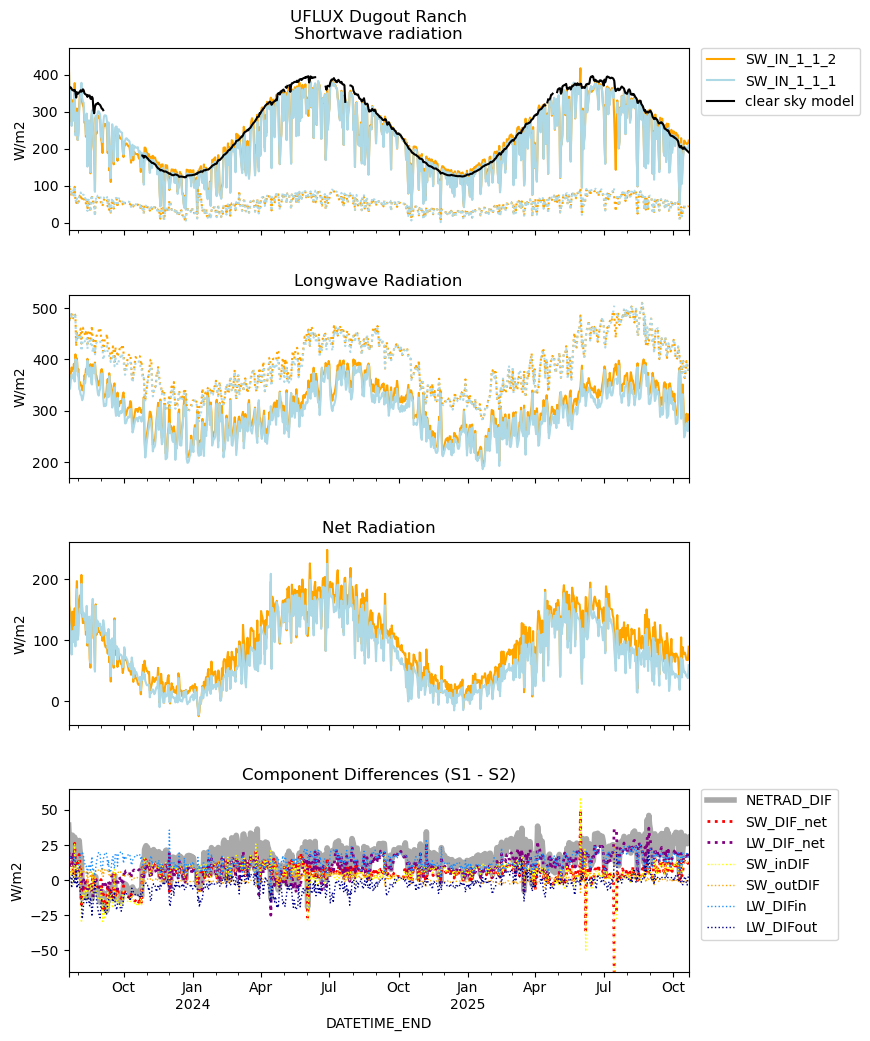

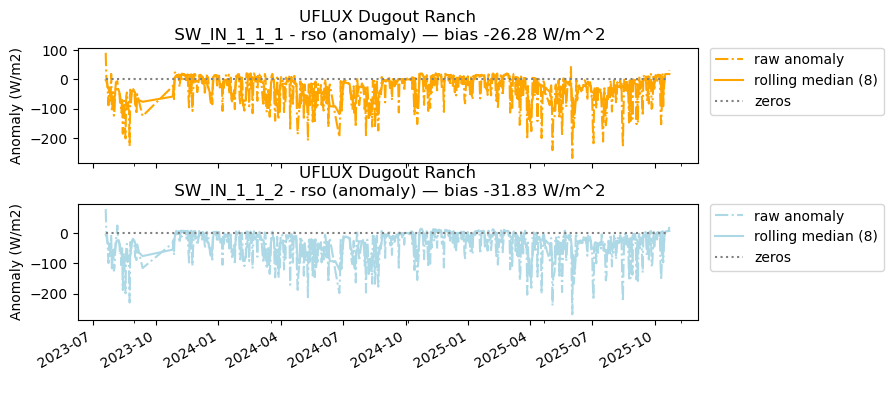

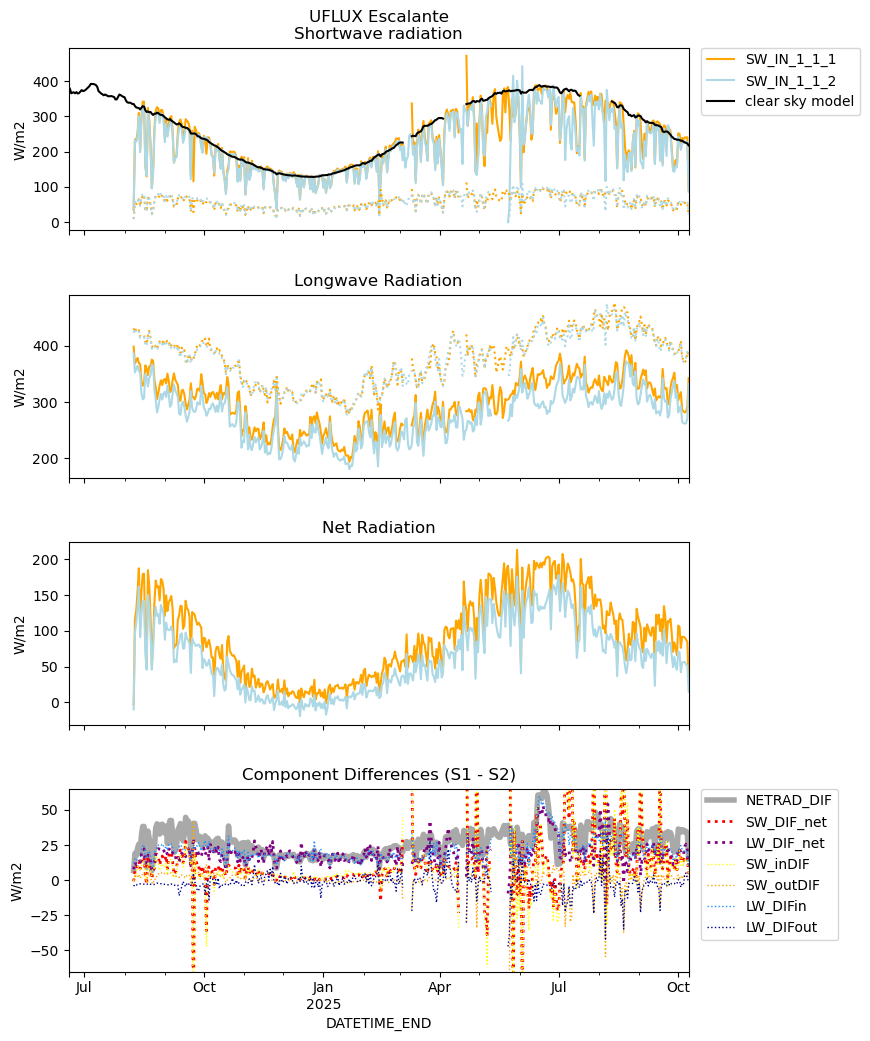

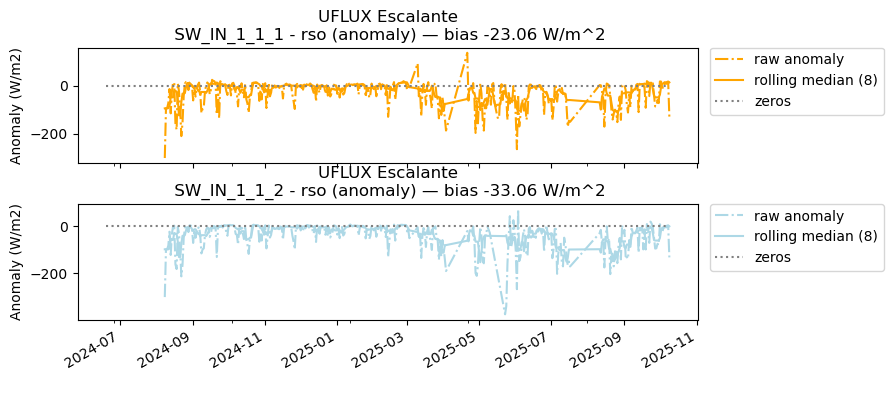

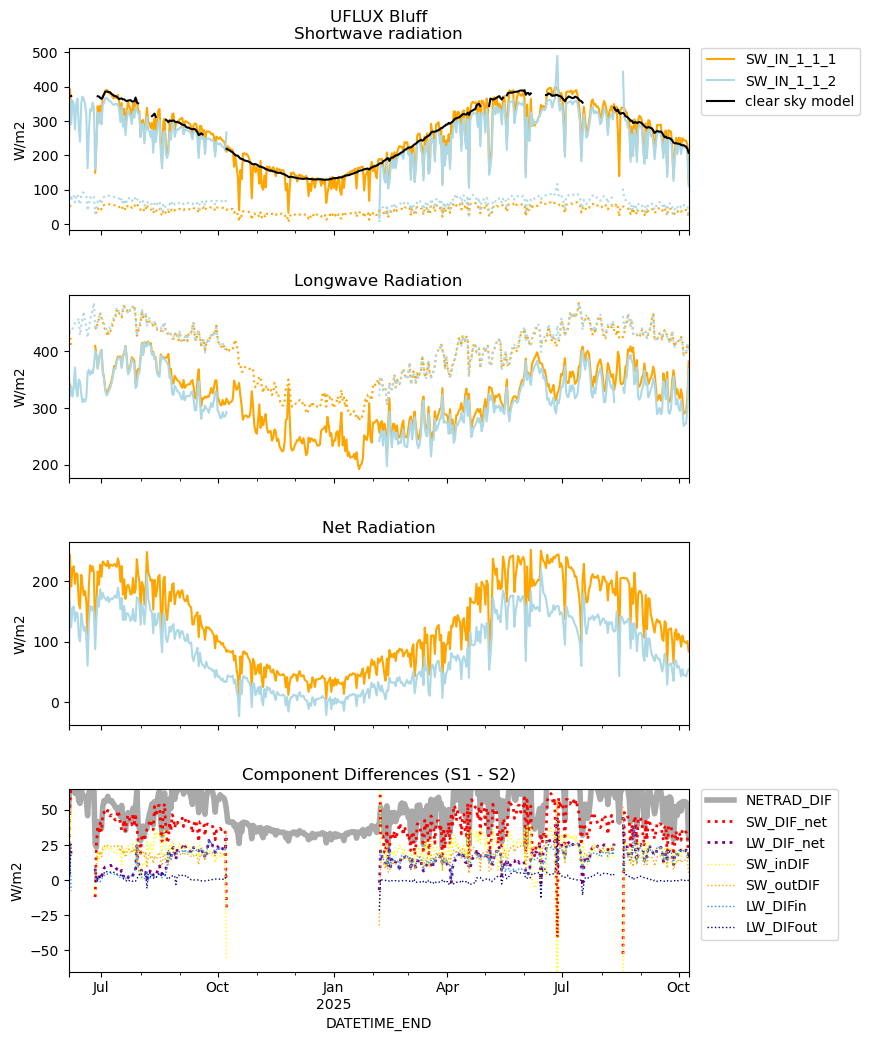

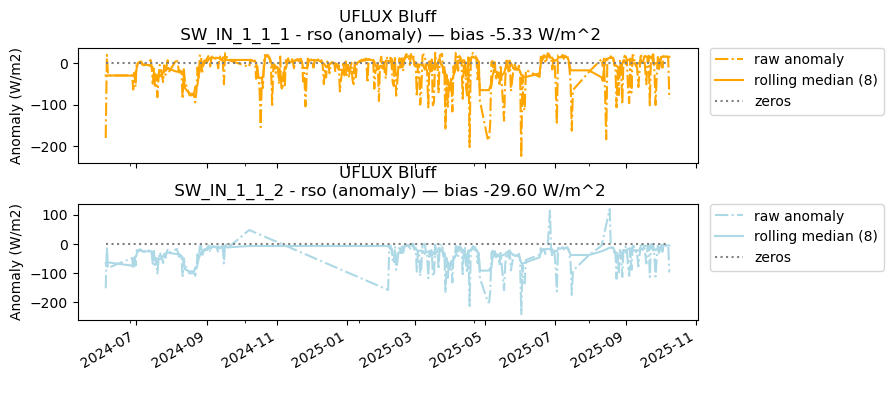

In [8]:
files = glob.glob('data/*/*.parquet')

for i in np.arange(len(files)):
    if glob.glob('/'.join(files[i].split('/')[:2])+'/*.ini')==[]:
        print('no data')
    else:
        print(glob.glob('/'.join(files[i].split('/')[:2])+'/*.ini')[0])
        ini_file = glob.glob('/'.join(files[i].split('/')[:2])+'/*.ini')[0]
        files_read = config.read(ini_file)
        loc_df_30minfull = pd.read_parquet(files[i])
        # print(loc_df_30minfull.columns)
        
        if not files_read:
            print(f"Error: config.ini not found or could not be read.")
        else:
            sitename = config['METADATA']['site_name']
            lat_dd = float(config['METADATA']['station_latitude'])
            elev_m = float(config['METADATA']['station_elevation'])
            tempname = config['DATA']['avg_temp_col']
            windname = config['DATA']['wind_spd_col']
            rs_name = config['DATA']['shortwave_in_col']
            print(rs_name)
            rs_out_name = config['DATA']['shortwave_out_col']
            print(rs_out_name)
            rh_name = config['DATA']['rel_humidity_col']
            wind_anemom_m = 1.0
        print(sitename)
        if rs_name.split('_')[-1]=='1':
            rs_name2 = 'SW_IN_1_1_2'
            rs_outname2 = 'SW_OUT_1_1_2'
            rs_outname = 'SW_OUT_1_1_1'
        else:
            rs_name2 = 'SW_IN_1_1_1'
            rs_outname2 = 'SW_OUT_1_1_1'
            rs_outname = 'SW_OUT_1_1_2'
            
        required_cols = {tempname,windname,rs_name,rh_name,rs_out_name,rs_name2,rs_outname2,'LW_IN_1_1_1','LW_OUT_1_1_1','LW_IN_1_1_2','LW_OUT_1_1_2','NETRAD_1_1_1_FINAL','NETRAD_1_1_2_FINAL'}
        if required_cols.issubset(loc_df_30minfull.columns):
            print("All required columns are present.")
        
            #prep data for agweather
            loc_df_30min = loc_df_30minfull[[tempname,windname,rs_name,rh_name,rs_out_name,rs_name2,rs_outname2,'LW_IN_1_1_1','LW_OUT_1_1_1','LW_IN_1_1_2','LW_OUT_1_1_2','NETRAD_1_1_1_FINAL','NETRAD_1_1_2_FINAL']].copy()
            loc_df_30min["es_kPa"] = 0.6108 * np.exp((17.27 * loc_df_30min[tempname]) / (loc_df_30min[tempname] + 237.3))
            loc_df_30min["ea_kPa"] = (loc_df_30min[rh_name] / 100.0) * loc_df_30min["es_kPa"]
            loc_df_day = loc_df_30min.resample('d').mean()
            loc_df_day['doy']=loc_df_day.index.dayofyear
            loc_df_day['month']=loc_df_day.index.month
            loc_df_daymax = loc_df_30min.resample('d').max()
            loc_df_daymin = loc_df_30min.resample('d').min()
            loc_df_daymax['doy']=loc_df_daymax.index.dayofyear
            loc_df_daymax['month']=loc_df_daymax.index.month
            
            tmax = loc_df_daymax[tempname].to_numpy()
            tmin = loc_df_daymin[tempname].to_numpy()
            lat =lat_dd*np.ones(len(tmax))
            elev=elev_m*np.ones(len(tmax))
            wind_anemom = wind_anemom_m*np.ones(len(tmax))
            doy = loc_df_day['doy'].to_numpy()
            month = loc_df_day['month'].to_numpy()
            ea = loc_df_day['ea_kPa'].to_numpy()
            ws = loc_df_day[windname].to_numpy()
            rs = loc_df_day[rs_name].to_numpy()
            print(rs.shape)
            
            # Sourced from AgWeather QAQC
            # agweatherqaqc.calc_functions.calc_rso_and_refet()
            rso, rs_m, eto, etr, eto_m, etr_m = awqc.calc_functions.calc_rso_and_refet(lat, elev, wind_anemom, doy, month, tmax, tmin, ea, ws, rs)
            
            loc_df_day['rso']=rso
            loc_df_day['etr']=etr
            
            # try:
            diag_netrad(loc_df_day,site=sitename,sensor1name = rs_name,sensor2name = rs_name2)
            plot_sensor_anomalies(loc_df_day, site=sitename,
                              rso_col='rso',
                              sensors=('SW_IN_1_1_1','SW_IN_1_1_2'),
                              rolling_window=8,
                              start=None,
                              end=None)
        else:
            print("One or more required columns are missing.")
        
        
        # print('Not all data is available')
        # # continue